In [4]:
pip install xgboost imbalanced-learn

Defaulting to user installation because normal site-packages is not writeable
  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (
    accuracy_score, roc_auc_score, f1_score,
    precision_score, recall_score, classification_report,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.preprocessing   import StandardScaler
from imblearn.over_sampling  import SMOTE
from xgboost                 import XGBClassifier

BASE      = r"C:\Users\mukul\Desktop\Projects\patient-readmission-prediction"
DATA_PROC = os.path.join(BASE, "data", "processed")
MODELS    = os.path.join(BASE, "models")
REPORTS   = os.path.join(BASE, "reports")

os.makedirs(MODELS,  exist_ok=True)
os.makedirs(REPORTS, exist_ok=True)

sns.set_style("darkgrid")
plt.rcParams["figure.dpi"]     = 130
plt.rcParams["figure.figsize"] = (12, 5)

CYAN  = "#00e5ff"
RED   = "#ff4d6d"
GREEN = "#00f5a0"
AMBER = "#ffb347"

RANDOM_STATE = 42
print("Setup complete ✅")

Setup complete ✅


# 1. Load Processed Data

In [6]:
df = pd.read_csv(os.path.join(DATA_PROC, "patient_processed.csv"))
 
print(f"Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Readmission rate: {df['readmitted_30_days'].mean():.1%}")
df.head(3)
 

Loaded: 10,000 rows × 36 columns
Readmission rate: 32.2%


,patient_id,age,length_of_stay_days,num_previous_admissions,num_medications,hba1c,blood_glucose_mg_dl,systolic_bp_mmhg,creatinine_mg_dl,haemoglobin_g_dl,...,high_hba1c,high_glucose,high_bp,high_creatinine,low_haemoglobin,is_high_risk_diag,gender_encoded,discharge_encoded,insurance_encoded,readmitted_30_days
0,PTIND00001,26,2,3,1,6.1,101,134,0.5,12.0,...,0,0,0,0,0,0,1,2,4,0
1,PTIND00002,65,6,1,2,4.0,119,147,0.4,10.8,...,0,0,1,0,0,1,0,1,3,0
2,PTIND00003,27,1,0,11,6.0,107,110,0.4,12.3,...,0,0,0,0,0,0,0,0,0,0


# 2. Prepare Features & Target

In [7]:
DROP_COLS = ["patient_id"]
TARGET    = "readmitted_30_days"
 
X = df.drop(columns=DROP_COLS + [TARGET])
y = df[TARGET]
 
print(f"Features : {X.shape[1]}")
print(f"Samples  : {X.shape[0]:,}")
print(f"\nClass distribution:")
print(y.value_counts())
print(f"\nClass balance: {y.mean():.1%} positive (readmitted)")
 

Features : 34
Samples  : 10,000

Class distribution:
readmitted_30_days
0    6784
1    3216
Name: count, dtype: int64

Class balance: 32.2% positive (readmitted)


# 3. Train-Test Split

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    stratify     = y,
    random_state = RANDOM_STATE
)
 
print(f"Train size : {X_train.shape[0]:,} samples")
print(f"Test size  : {X_test.shape[0]:,} samples")
print(f"\nTrain class balance: {y_train.mean():.1%} readmitted")
print(f"Test class balance : {y_test.mean():.1%} readmitted")
 

Train size : 8,000 samples
Test size  : 2,000 samples

Train class balance: 32.2% readmitted
Test class balance : 32.1% readmitted


# Scale numeric features for Logistic Regression

In [21]:
scaler        = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
joblib.dump(scaler, os.path.join(MODELS, "scaler.pkl"))
print("\nScaler saved ✅")


Scaler saved ✅


# 4. Handle Class Imbalance (SMOTE)

#### Only ~32% of patients are readmitted.
#### SMOTE creates synthetic samples of the minority class
#### so the model learns both classes equally.

In [22]:
sm = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
 
print("Before SMOTE:")
print(f"  Readmitted     : {y_train.sum():,}")
print(f"  Not readmitted : {(y_train==0).sum():,}")
 
print("\nAfter SMOTE:")
print(f"  Readmitted     : {y_train_res.sum():,}")
print(f"  Not readmitted : {(y_train_res==0).sum():,}")
print(f"\nTotal training samples after SMOTE: {len(X_train_res):,}")


Before SMOTE:
  Readmitted     : 2,573
  Not readmitted : 5,427

After SMOTE:
  Readmitted     : 5,427
  Not readmitted : 5,427

Total training samples after SMOTE: 10,854


 
### Scale SMOTE data for Logistic Regression


In [23]:
X_train_res_scaled = scaler.transform(X_train_res)
 

# 5. Train Logistic Regression (Baseline)

In [10]:
print("Training Logistic Regression...")
 
lr = LogisticRegression(
    max_iter     = 1000,
    class_weight = "balanced",
    random_state = RANDOM_STATE
)
lr.fit(X_train_res_scaled, y_train_res)
 
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]
 
lr_metrics = {
    "Model"    : "Logistic Regression",
    "Accuracy" : round(accuracy_score(y_test, y_pred_lr), 4),
    "AUC-ROC"  : round(roc_auc_score(y_test, y_prob_lr), 4),
    "Precision": round(precision_score(y_test, y_pred_lr), 4),
    "Recall"   : round(recall_score(y_test, y_pred_lr), 4),
    "F1"       : round(f1_score(y_test, y_pred_lr), 4),
}
 
joblib.dump(lr, os.path.join(MODELS, "logistic_regression.pkl"))
print("Logistic Regression trained ✅")
print(pd.Series(lr_metrics))
 

Training Logistic Regression...
Logistic Regression trained ✅
Model        Logistic Regression
Accuracy                  0.6975
AUC-ROC                   0.6707
Precision                 0.5594
Recall                    0.2784
F1                        0.3718
dtype: object


# 6. Train Random Forest

In [11]:
print("Training Random Forest...")
 
rf = RandomForestClassifier(
    n_estimators = 200,
    max_depth    = 10,
    class_weight = "balanced",
    random_state = RANDOM_STATE,
    n_jobs       = -1
)
rf.fit(X_train_res, y_train_res)
 
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]
 
rf_metrics = {
    "Model"    : "Random Forest",
    "Accuracy" : round(accuracy_score(y_test, y_pred_rf), 4),
    "AUC-ROC"  : round(roc_auc_score(y_test, y_prob_rf), 4),
    "Precision": round(precision_score(y_test, y_pred_rf), 4),
    "Recall"   : round(recall_score(y_test, y_pred_rf), 4),
    "F1"       : round(f1_score(y_test, y_pred_rf), 4),
}
 
joblib.dump(rf, os.path.join(MODELS, "random_forest.pkl"))
print("Random Forest trained ✅")
print(pd.Series(rf_metrics))
 

Training Random Forest...
Random Forest trained ✅
Model        Random Forest
Accuracy            0.6385
AUC-ROC             0.6362
Precision           0.4331
Recall              0.4028
F1                  0.4174
dtype: object


# 7. Train XGBoost (Best Model)

In [12]:
print("Training XGBoost...")
 
scale_pos_weight = (y_train_res == 0).sum() / (y_train_res == 1).sum()
 
xgb = XGBClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    scale_pos_weight  = scale_pos_weight,
    random_state      = RANDOM_STATE,
    eval_metric       = "auc",
    verbosity         = 0
)
xgb.fit(
    X_train_res, y_train_res,
    eval_set  = [(X_test, y_test)],
    verbose   = False
)
 
y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]
 
xgb_metrics = {
    "Model"    : "XGBoost",
    "Accuracy" : round(accuracy_score(y_test, y_pred_xgb), 4),
    "AUC-ROC"  : round(roc_auc_score(y_test, y_prob_xgb), 4),
    "Precision": round(precision_score(y_test, y_pred_xgb), 4),
    "Recall"   : round(recall_score(y_test, y_pred_xgb), 4),
    "F1"       : round(f1_score(y_test, y_pred_xgb), 4),
}
 
joblib.dump(xgb, os.path.join(MODELS, "xgboost_model.pkl"))
print("XGBoost trained ✅")
print(pd.Series(xgb_metrics))
 

Training XGBoost...
XGBoost trained ✅
Model        XGBoost
Accuracy       0.652
AUC-ROC       0.6409
Precision     0.4365
Recall         0.283
F1            0.3434
dtype: object


# 8. Compare All Models

MODEL COMPARISON
                     Accuracy  AUC-ROC  Precision  Recall      F1
Model                                                            
Logistic Regression    0.6975   0.6707     0.5594  0.2784  0.3718
Random Forest          0.6385   0.6362     0.4331  0.4028  0.4174
XGBoost                0.6520   0.6409     0.4365  0.2830  0.3434

Best model by AUC-ROC : Logistic Regression
Best model by F1      : Random Forest
Best model by Recall  : Random Forest


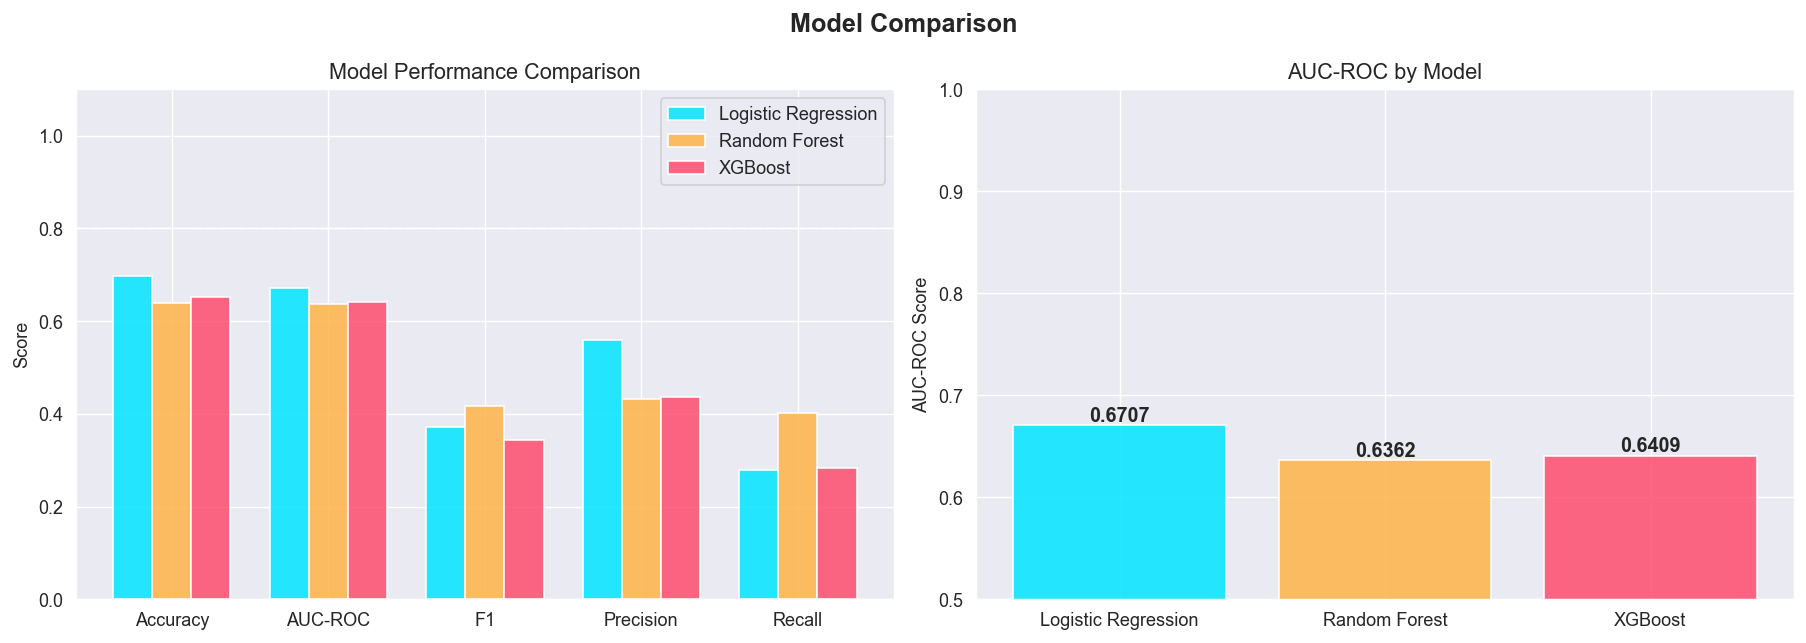

In [13]:
results = pd.DataFrame([lr_metrics, rf_metrics, xgb_metrics])
results = results.set_index("Model")
 
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)
print(results.to_string())
print("=" * 60)
print(f"\nBest model by AUC-ROC : {results['AUC-ROC'].idxmax()}")
print(f"Best model by F1      : {results['F1'].idxmax()}")
print(f"Best model by Recall  : {results['Recall'].idxmax()}")
 
# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
metrics_to_plot = ["Accuracy", "AUC-ROC", "F1", "Precision", "Recall"]
x = np.arange(len(metrics_to_plot))
width = 0.25
colors_bar = [CYAN, AMBER, RED]
 
for i, (model, color) in enumerate(zip(results.index, colors_bar)):
    vals = [results.loc[model, m] for m in metrics_to_plot]
    bars = axes[0].bar(x + i*width, vals, width, label=model,
                       color=color, edgecolor="white", alpha=0.85)
 
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics_to_plot)
axes[0].set_ylabel("Score")
axes[0].set_title("Model Performance Comparison")
axes[0].legend()
axes[0].set_ylim(0, 1.1)
axes[0].axhline(0.8, color="white", linestyle="--", alpha=0.3)
 
# AUC-ROC bar
auc_vals = results["AUC-ROC"].values
bars = axes[1].bar(results.index, auc_vals,
                   color=colors_bar, edgecolor="white", alpha=0.85)
axes[1].set_ylabel("AUC-ROC Score")
axes[1].set_title("AUC-ROC by Model")
axes[1].set_ylim(0.5, 1.0)
for bar, val in zip(bars, auc_vals):
    axes[1].annotate(f"{val:.4f}",
                     (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha="center", va="bottom", fontsize=11, fontweight="bold")
 
plt.suptitle("Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, "12_model_comparison.png"), bbox_inches="tight")
plt.show()
 

# 9. ROC Curves


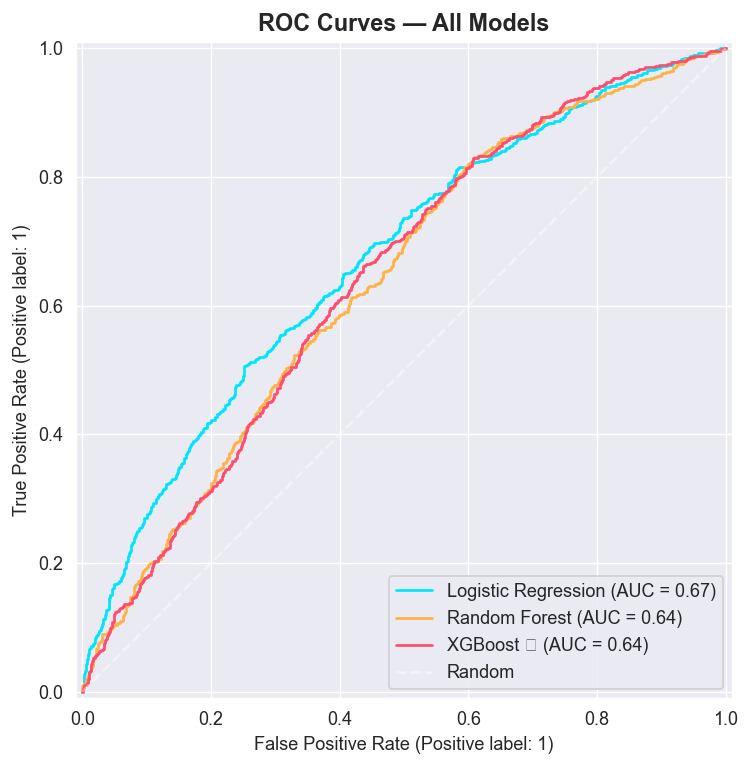

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
 
RocCurveDisplay.from_predictions(y_test, y_prob_lr,  ax=ax, name="Logistic Regression", color=CYAN)
RocCurveDisplay.from_predictions(y_test, y_prob_rf,  ax=ax, name="Random Forest",       color=AMBER)
RocCurveDisplay.from_predictions(y_test, y_prob_xgb, ax=ax, name="XGBoost ✅",          color=RED)
 
ax.plot([0,1],[0,1], "w--", alpha=0.4, label="Random")
ax.set_title("ROC Curves — All Models", fontsize=13, fontweight="bold")
ax.legend(loc="lower right")
 
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, "13_roc_curves.png"), bbox_inches="tight")
plt.show()
 

# 10. Confusion Matrix (XGBoost)

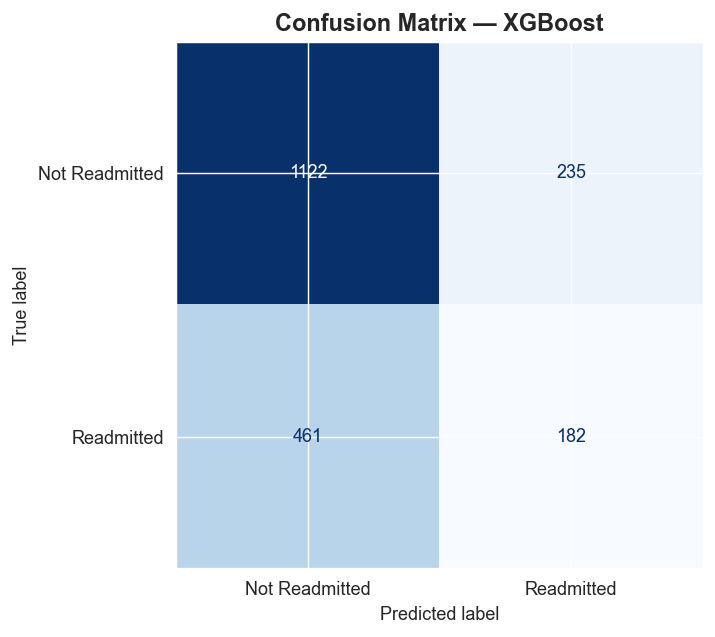


XGBoost Classification Report:
                precision    recall  f1-score   support

Not Readmitted       0.71      0.83      0.76      1357
    Readmitted       0.44      0.28      0.34       643

      accuracy                           0.65      2000
     macro avg       0.57      0.55      0.55      2000
  weighted avg       0.62      0.65      0.63      2000



In [24]:
fig, ax = plt.subplots(figsize=(6, 5))
 
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_xgb,
    ax             = ax,
    colorbar       = False,
    display_labels = ["Not Readmitted", "Readmitted"],
    cmap           = "Blues"
)
ax.set_title("Confusion Matrix — XGBoost", fontsize=13, fontweight="bold")
 
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, "14_confusion_matrix.png"), bbox_inches="tight")
plt.show()
 
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=["Not Readmitted", "Readmitted"]))
 

# 11. Feature Importance (XGBoost)

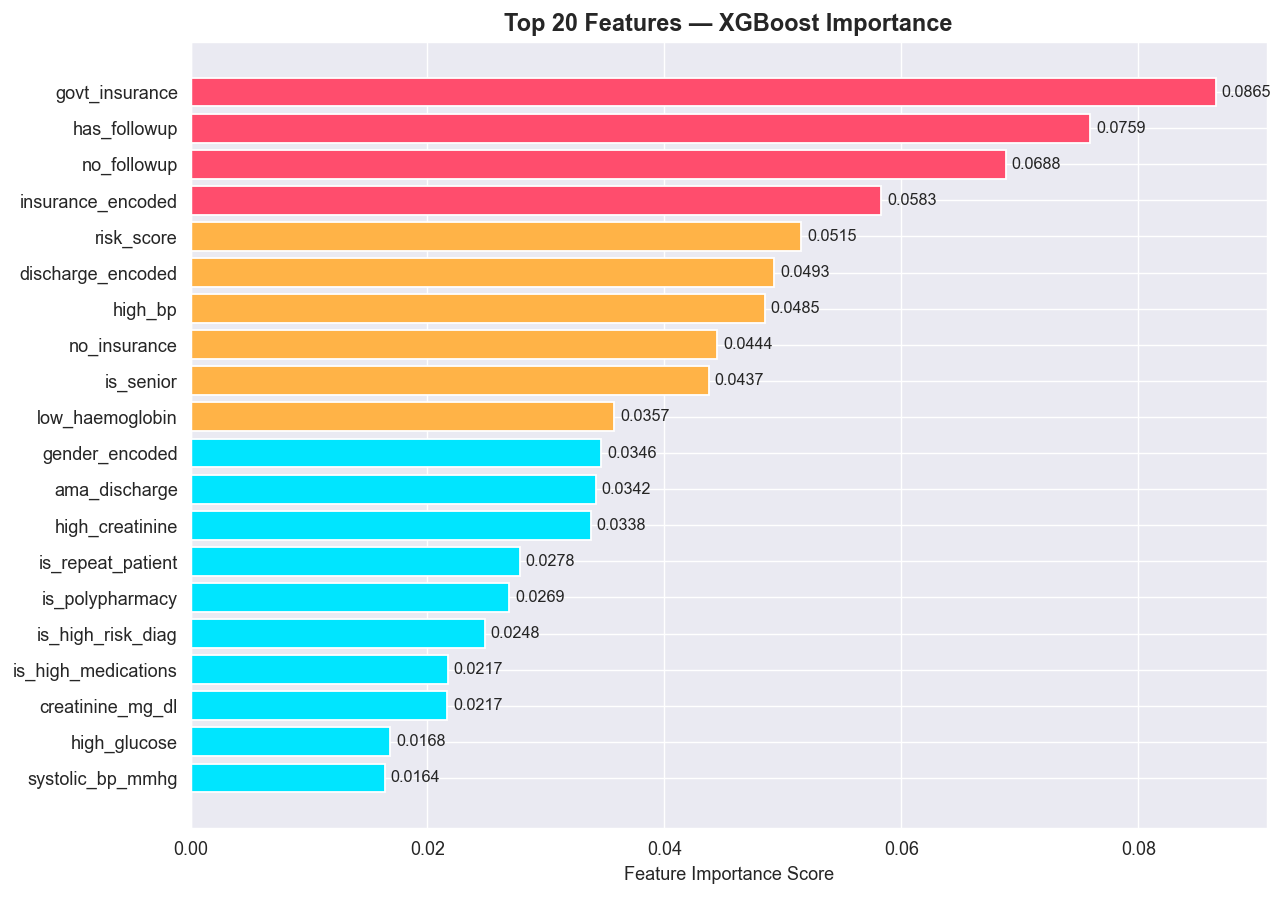

In [16]:
importance = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=True).tail(20)
 
fig, ax = plt.subplots(figsize=(10, 7))
colors_imp = [RED if v > importance.quantile(0.8)
              else AMBER if v > importance.quantile(0.5)
              else CYAN for v in importance.values]
 
bars = ax.barh(importance.index, importance.values,
               color=colors_imp, edgecolor="white")
ax.set_xlabel("Feature Importance Score")
ax.set_title("Top 20 Features — XGBoost Importance", fontsize=13, fontweight="bold")
 
for bar, val in zip(bars, importance.values):
    ax.text(val + 0.0005, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=9)
 
plt.tight_layout()
plt.savefig(os.path.join(REPORTS, "15_feature_importance.png"), bbox_inches="tight")
plt.show()
 

# 12. Save Best Model & Results

In [17]:
# Save metrics to CSV
results.to_csv(os.path.join(REPORTS, "model_metrics.csv"))
 
# Save feature columns list (needed for Streamlit app)
feature_cols = list(X.columns)
joblib.dump(feature_cols, os.path.join(MODELS, "feature_columns.pkl"))
 
print("=" * 55)
print("TRAINING COMPLETE")
print("=" * 55)
print(f"Models saved to     : {MODELS}")
print(f"Reports saved to    : {REPORTS}")
print(f"\nFiles saved:")
print(f"  models/xgboost_model.pkl")
print(f"  models/random_forest.pkl")
print(f"  models/logistic_regression.pkl")
print(f"  models/scaler.pkl")
print(f"  models/feature_columns.pkl")
print(f"  reports/model_metrics.csv")
print(f"\nBest Model  : XGBoost")
print(f"AUC-ROC     : {xgb_metrics['AUC-ROC']}")
print(f"F1 Score    : {xgb_metrics['F1']}")
print(f"\n✅ Ready for SHAP Explainability (Notebook 04)")
 

TRAINING COMPLETE
Models saved to     : C:\Users\mukul\Desktop\Projects\patient-readmission-prediction\models
Reports saved to    : C:\Users\mukul\Desktop\Projects\patient-readmission-prediction\reports

Files saved:
  models/xgboost_model.pkl
  models/random_forest.pkl
  models/logistic_regression.pkl
  models/scaler.pkl
  models/feature_columns.pkl
  reports/model_metrics.csv

Best Model  : XGBoost
AUC-ROC     : 0.6409
F1 Score    : 0.3434

✅ Ready for SHAP Explainability (Notebook 04)
